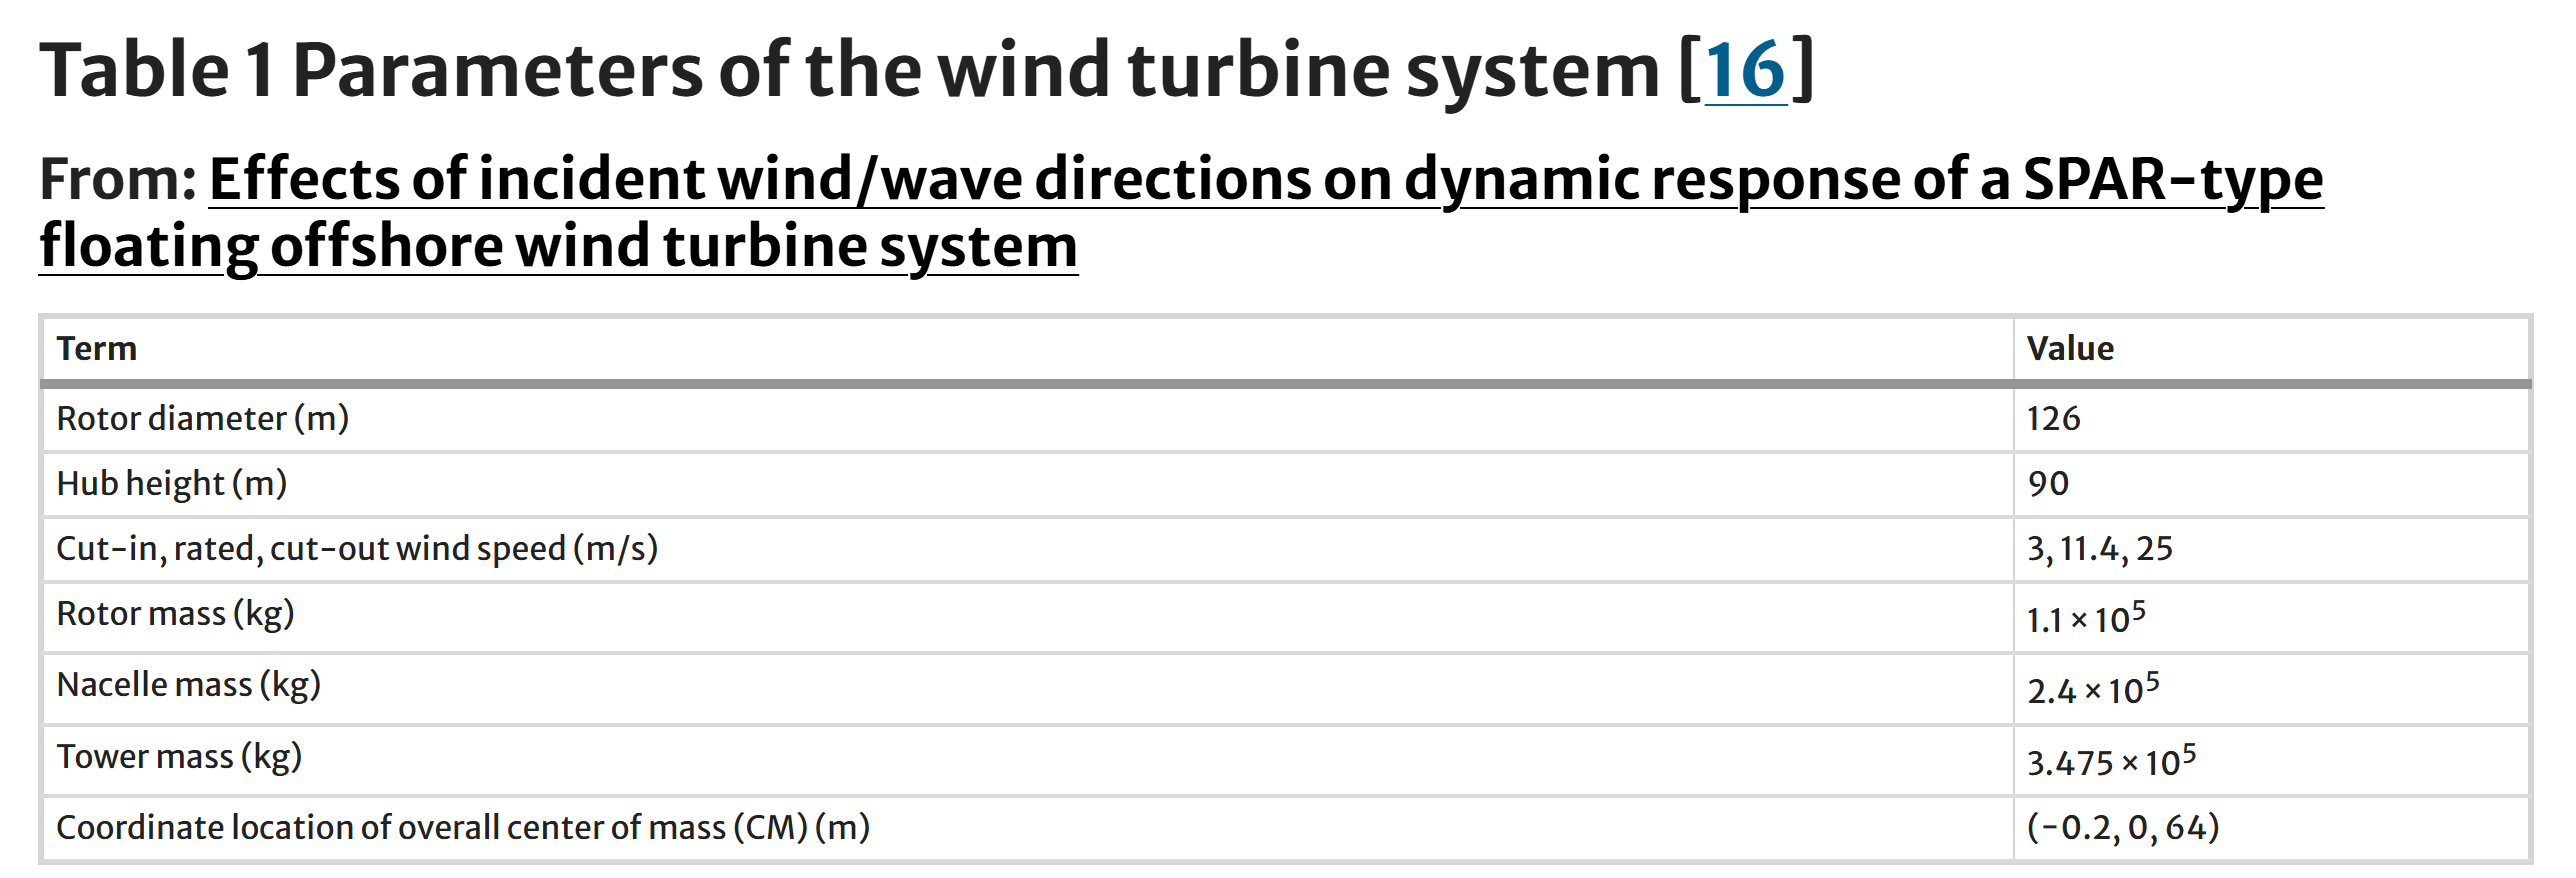

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt


data_dir= r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\data aquisition\data'
eva_dir = r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\EVA'
power_production_dir = r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\power_production'

#load wind data
df_wind = pd.read_csv(f"{data_dir}/wind_data_sines_2010_2020.csv", index_col=0, parse_dates=True)

#check timestep
dt= df_wind.index[1] - df_wind.index[0]
dt_hours = dt.total_seconds() / 3600
print(f"Time step: {dt_hours:.2f} hours")
print(f"Total records: {len(df_wind)}")
print (f"Data range: {df_wind.index[0]} to {df_wind.index[-1]}")

Time step: 3.00 hours
Total records: 32144
Data range: 2010-01-01 00:00:00 to 2020-12-31 21:00:00


In [3]:

#correction hub height
alpha = 0.14
z_ref = 100  # m
z_hub = 90  # m
df_wind['U_hub'] = df_wind['wind_speed_100m_ms'] * (z_hub / z_ref)**alpha


print(f"Mean wind speed at 100 m: {df_wind['wind_speed_100m_ms'].mean():.2f} m/s")
print(f"Mean wind speed at hub height (90 m): {df_wind['U_hub'].mean():.2f} m/s")

Mean wind speed at 100 m: 7.29 m/s
Mean wind speed at hub height (90 m): 7.19 m/s


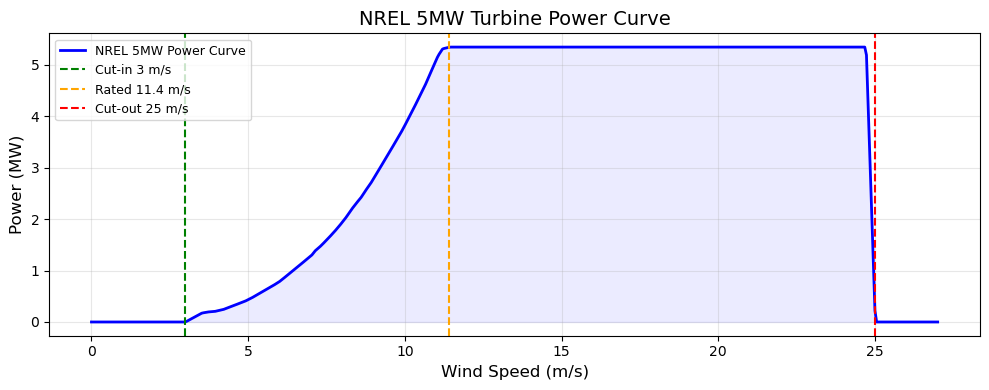

Mean power at hub height: 1935.51 kW
% time at rated power    : 14.4%
% time producing power   : 89.3%
% time below cut-in      : 10.7%
% time above cut-out     : 0.0%


In [26]:

# power curve digitised from figure 9-1 


gen_dig = np.array([
    [3.189189,   49.18],   # near cut-in
    [3.459459,   98.36],
    [6.642438,  1028.43],
    [6.864281,  1131.85],
    [7.086123,  1239.17],
    [7.307965,  1364.27],
    [7.529808,  1494.94],
    [7.740650,  1604.20],
    [7.891892,  1721.31],
    [8.054162,  1834.43],
    [8.235670,  1972.39],
    [8.417177,  2108.99],
    [8.608768,  2250.48],
    [8.780192,  2388.30],
    [8.921364,  2497.72],
    [9.082704,  2632.67],
    [9.223876,  2765.48],
    [9.365049,  2900.04],
    [9.506221,  3035.47],
    [9.647394,  3167.41],
    [9.788566,  3301.10],
    [9.929738,  3433.91],
    [10.060827, 3563.66],
    [10.189189, 3688.52],
    [10.317962, 3822.08],
    [10.384947, 3971.28],
    [10.585182, 4135.54],
    [10.706187, 4279.28],
    [10.827191, 4416.90],
    [10.938113, 4556.35],
    [11.049034, 4698.25],
    [11.159955, 4840.15],
    [11.297297, 4983.61],
    [11.460787, 5044.33],
    [11.684310, 5049.11],
    [11.906152, 5049.11],
    [12.127994, 5053.00],
    [13.015364, 5053.00],
    [14.124575, 5053.00],
    [15.011945, 5053.00],
    [16.121156, 5053.00],
    [17.008526, 5053.00],
    [18.117737, 5053.00],
    [19.005107, 5053.00],
    [20.114318, 5053.00],
    [21.001688, 5053.00],
    [22.110900, 5053.00],
    [23.220111, 5053.00],
    [24.329323, 5053.00],
    [24.773008, 5053.00],
    [25.000000,    0.00],  # cut-out
])

pc_wind  = gen_dig[:, 0]
pc_power = gen_dig[:, 1]


#add boundary points: zero before cutin and after cut-out
U_pc = np.concatenate(([0.9, 3.0], U_dig, [25.01, 50.0]))
P_pc = np.concatenate(([0.0, 0.0], P_dig, [0.0, 0.0]))

#apply to time series 
df_wind['power_kW'] = np.interp(df_wind['U_hub'], U_pc, P_pc)

#plot power curve


u_plot = np.linspace(0, 27, 500)

p_range = np.interp(u_plot, U_pc, P_pc)/1000  # convert to MW 

plt.figure(figsize=(10, 4))
plt.plot(u_plot, p_range, 'b-', linewidth = 2, label = 'NREL 5MW Power Curve')
plt.axvline(3, color='green', linestyle='--', label='Cut-in 3 m/s')
plt.axvline(11.4, color='orange', linestyle='--', label='Rated 11.4 m/s')
plt.axvline(25, color='red', linestyle='--', label='Cut-out 25 m/s')
plt.fill_between(u_plot, p_range, alpha=0.08, color='blue')
plt.xlabel('Wind Speed (m/s)', fontsize=12)
plt.ylabel('Power (MW)', fontsize=12)
plt.title('NREL 5MW Turbine Power Curve', fontsize=14)
plt.legend(fontsize=9, loc='upper left') 
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.savefig(f"{power_production_dir}/wind_power_curve.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Mean power at hub height: {df_wind['power_kW'].mean():.2f} kW")
print(f"% time at rated power    : {(df_wind['power_kW'] >= 4999).mean()*100:.1f}%")
print(f"% time producing power   : {((df_wind['U_hub'] >= 3) & (df_wind['U_hub'] <= 25)).mean()*100:.1f}%")
print(f"% time below cut-in      : {(df_wind['U_hub'] < 3).mean()*100:.1f}%")
print(f"% time above cut-out     : {(df_wind['U_hub'] > 25).mean()*100:.1f}%")

Jonkman et al. (2009), NREL/TP-500-38060 

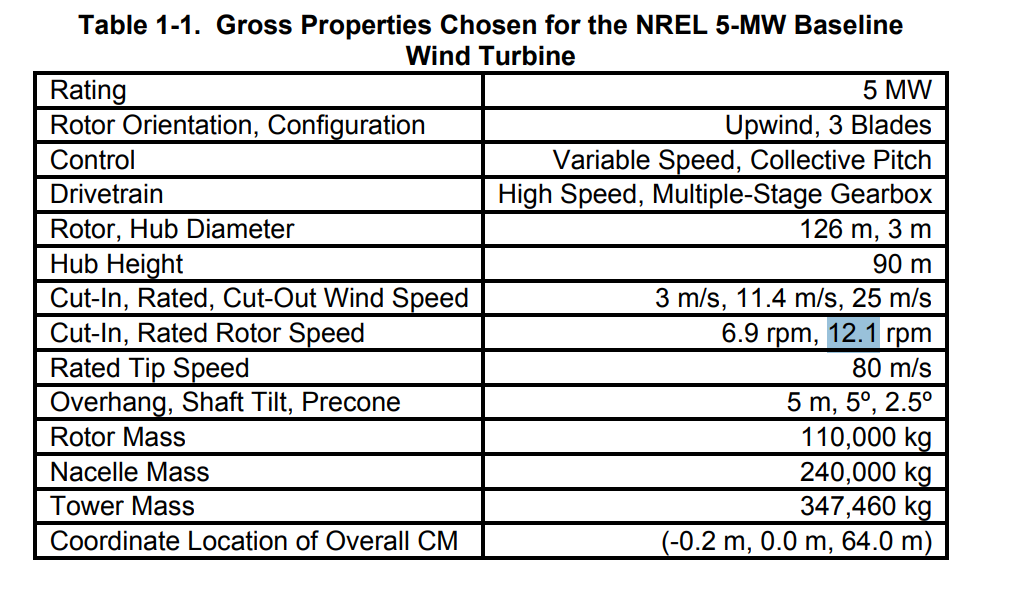

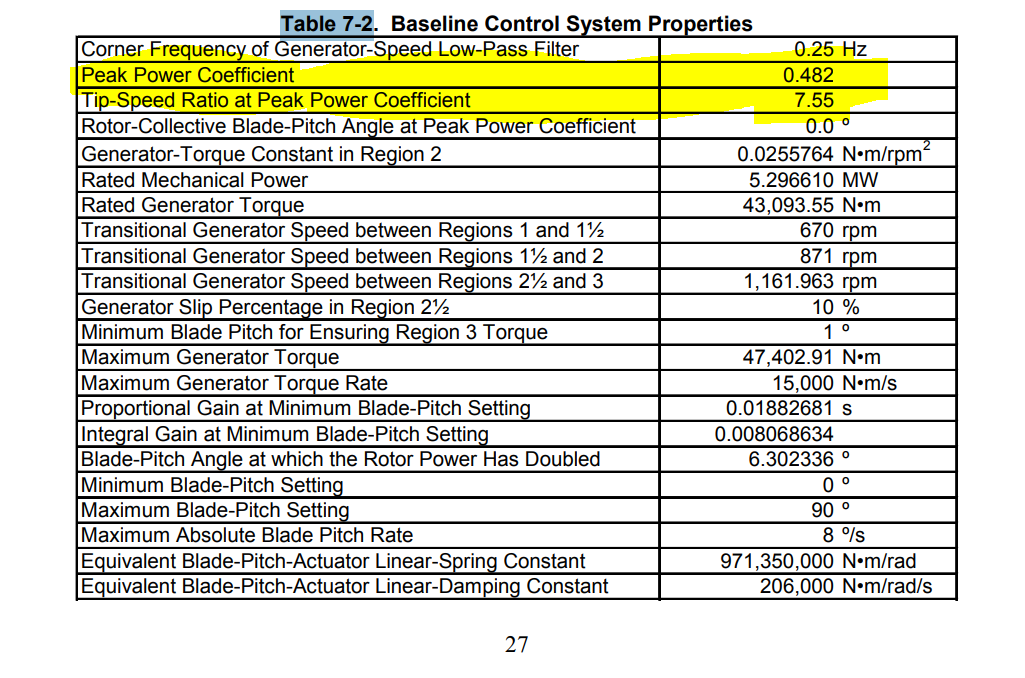

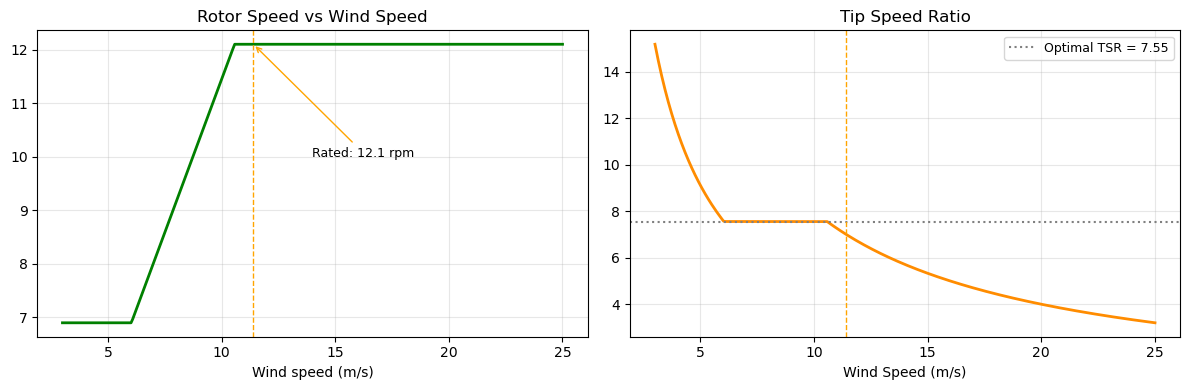

TSR at rated (11.4 m/s): 7.00  (expected ≈ 7.0, by design)
TSR at optimal (8 m/s) : 7.55  (should be ≈ 7.55)


In [27]:
#tip speed ratio
R = 63  # m rotor radius
omega_min = 6.9 # rpm
omega_rated = 12.1  # rpm
U_cut_in = 3  # m/s
U_rated = 11.4  # m/s
U_cut_out = 25  # m/s
TSR_opt = 7.55  # optimal tip speed ratio

U_vec = np.linspace(U_cut_in, U_cut_out, 300)

Omega_rads = np.clip(TSR_opt * U_vec / R, omega_min * 2 * np.pi / 60, omega_rated * 2 * np.pi / 60)

Omega_rpm = Omega_rads * 60 / (2 * np.pi)
TSR_vec = Omega_rads * R / U_vec

df_wind['Omega_rads'] = np.clip(TSR_opt * df_wind['U_hub'] / R,
                                 omega_min   * 2*np.pi/60,
                                 omega_rated * 2*np.pi/60)
df_wind.loc[df_wind['U_hub'] < U_cut_in,  'Omega_rads'] = 0
df_wind.loc[df_wind['U_hub'] > U_cut_out, 'Omega_rads'] = 0

df_wind['Omega_rpm'] = df_wind['Omega_rads'] * 60 / (2*np.pi)
df_wind['TSR'] = np.where(df_wind['U_hub'] >= U_cut_in,
                           df_wind['Omega_rads'] * R / df_wind['U_hub'].replace(0, np.nan),
                           0)

#plot

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(U_vec, Omega_rpm, 'g-', linewidth=2)
ax1.axvline(U_rated, color='orange', linestyle='--', linewidth=1)
ax1.set_xlabel('Wind speed (m/s)', fontsize=10)
ax1.set_title('Rotor Speed vs Wind Speed', fontsize=12)
ax1.annotate(f'Rated: {omega_rated} rpm', xy=(U_rated, omega_rated),
              xytext=(14, 10), fontsize=9,
              arrowprops=dict(arrowstyle='->', color='orange'))
ax1.grid(True, alpha=0.3)

ax2.plot(U_vec, TSR_vec, 'darkorange', linewidth=2)
ax2.axhline(TSR_opt, color='gray', linestyle=':', linewidth=1.5,
             label=f'Optimal TSR = {TSR_opt}')
ax2.axvline(U_rated, color='orange', linestyle='--', linewidth=1)
ax2.set_xlabel('Wind Speed (m/s)', fontsize=10)
ax2.set_title('Tip Speed Ratio', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{power_production_dir}/rotor_speed_tsr.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"TSR at rated (11.4 m/s): {np.interp(11.4, U_vec, TSR_vec):.2f}  (expected ≈ 7.0, by design)")
print(f"TSR at optimal (8 m/s) : {np.interp(8.0,  U_vec, TSR_vec):.2f}  (should be ≈ 7.55)")

how fast the blade tip moves relative to the wind.  
too slow--> waste of energy 
too fast --> more aerodynamic losses   
at 7.55 CP (power coefficient) is maximised 

"The rotor speed control strategy of the NREL 5-MW turbine is designed to maximise power capture in Region 2 by maintaining the optimal tip-speed ratio of λ = 7.55 (Jonkman et al. 2009, Table 7-2), corresponding to the peak power coefficient Cp = 0.482. Above rated wind speed (11.4 m/s), the rotor speed is fixed at 12.1 rpm and blade pitch control takes over, causing TSR to decrease. This transition represents a deliberate trade-off between aerodynamic efficiency and structural/electrical constraints — the turbine sacrifices optimal energy capture to protect the drivetrain and maintain constant rated power output."

https://automeris.io/wpd/

In [28]:
#single turbine AEP and CF

n_years= df_wind.index.year.nunique()
P_rated_kW = 5000 #kW

AEP_total_kWh = df_wind['power_kW'].sum() * (dt_hours)  # kWh
AEP_annual_kWh = AEP_total_kWh / n_years
AEP_annual_MWh = AEP_annual_kWh / 1000
AEP_annual_GWh = AEP_annual_MWh / 1000

CF = AEP_annual_kWh / (P_rated_kW * 8760)

print(f"Timestep (dt)          : {dt_hours:.2f} h")
print(f"Data period            : {n_years} years  ({df_wind.index[0].date()} – {df_wind.index[-1].date()})")
print(f"Total AEP (full record): {AEP_total_kWh/1e6:.3f} TWh")
print(f"Annual AEP  (1 turbine): {AEP_annual_MWh:.1f}  MWh/yr")
print(f"Annual AEP  (1 turbine): {AEP_annual_GWh:.4f} GWh/yr")
print(f"Capacity Factor        : {CF*100:.1f}%")


Timestep (dt)          : 3.00 h
Data period            : 11 years  (2010-01-01 – 2020-12-31)
Total AEP (full record): 186.645 TWh
Annual AEP  (1 turbine): 16967.7  MWh/yr
Annual AEP  (1 turbine): 16.9677 GWh/yr
Capacity Factor        : 38.7%


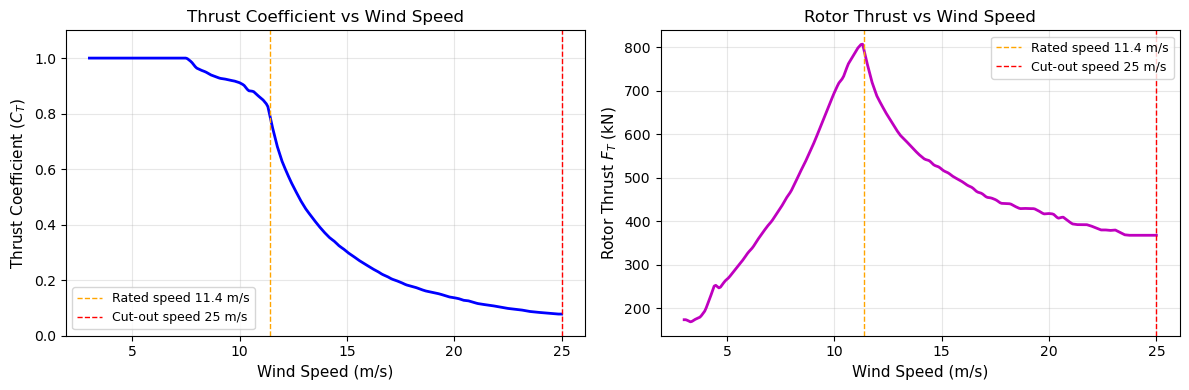

Peak CT ≈ 1.000  at U = 3.1 m/s
CT at rated (11.4 m/s) ≈ 0.795
Peak thrust ≈ 809 kN  at U = 11.3 m/s


In [29]:
# Thrust coefficient curve 

rho = 1.225  # kg/m³
R = 63  # m rotor radius
A = np.pi * R**2  # m² swept area

#digitised from figure 9-1
thrust_dig = np.array([
    [3.087919, 173.9726],  [3.314803, 168.6162],  [3.536646, 175.4739],
    [3.756757, 180.3279],  [3.980330, 195.2131],  [4.202173, 223.8488],
    [4.424015, 254.8014],  [4.648649, 245.9016],  [4.891892, 262.2951],
    [5.089542, 271.1117],  [5.311384, 285.0125],  [5.533227, 298.9133],
    [5.755069, 312.2582],  [5.972973, 327.8689],  [6.198754, 340.0598],
    [6.420596, 357.2969],  [6.642438, 372.8658],  [6.864281, 387.8787],
    [7.086123, 400.6675],  [7.307965, 417.3485],  [7.529808, 433.4735],
    [7.755011, 452.9810],  [7.973492, 468.5036],  [8.195335, 490.7449],
    [8.417177, 514.0983],  [8.639019, 535.7836],  [8.860862, 559.6931],
    [9.082704, 584.1585],  [9.304546, 611.4042],  [9.526389, 638.0938],
    [9.748231, 665.8955],  [9.970073, 692.5851],  [10.191916, 716.4945],
    [10.405355, 729.7466], [10.635600, 760.4212], [10.857443, 778.2142],
    [11.079285, 797.1194], [11.301127, 809.3521], [11.522970, 762.6453],
    [11.764980, 717.0505], [11.986822, 686.4687], [12.208664, 665.8955],
    [12.430507, 646.4343], [12.652349, 629.1972], [12.874191, 610.8481],
    [13.096034, 595.8352], [13.317876, 585.2706], [13.539718, 573.5939],
    [13.761561, 561.9172], [13.983403, 551.3526], [14.205245, 542.4560],
    [14.427088, 539.1198], [14.648930, 528.5552], [14.870772, 524.6629],
    [15.092615, 515.7664], [15.314457, 510.7621], [15.536299, 502.4216],
    [15.758142, 496.3052], [15.979984, 490.1889], [16.201826, 482.4044],
    [16.423669, 477.4001], [16.645511, 467.3915], [16.867353, 464.0553],
    [17.089196, 455.1588], [17.311038, 453.4907], [17.532880, 449.0424],
    [17.754723, 441.2579], [17.976565, 440.7019], [18.198407, 440.1459],
    [18.420250, 434.0295], [18.642092, 429.0252], [18.863934, 429.5812],
    [19.085777, 429.0252], [19.307619, 429.0252], [19.529461, 423.4649],
    [19.751304, 416.7925], [19.973146, 417.9045], [20.194988, 416.7925],
    [20.416831, 406.7838], [20.648649, 409.8361], [20.860515, 401.7795],
    [21.082358, 393.9951], [21.304200, 392.3270], [21.526042, 392.3270],
    [21.747885, 392.3270], [21.969727, 388.9908], [22.191569, 384.5425],
    [22.413412, 380.0942], [22.635254, 380.0942], [22.857096, 378.9822],
    [23.078939, 380.0942], [23.300781, 374.5339], [23.522624, 368.9736],
    [23.744466, 367.8615], [23.966308, 367.8615], [24.188151, 367.8615],
    [24.409993, 367.8615], [24.631835, 367.8615], [24.843594, 367.8615],
])



U_T = thrust_dig[:, 0]
F_T = thrust_dig[:, 1] * 1000  # convert from kN to N
CT = np.clip(F_T / (0.5 * rho * A * U_T**2), 0, 1.0)  # limit CT to 1.0 max

#interpolate
U_smooth = np.linspace(3, 25, 300)
CT_smooth = np.interp(U_smooth, U_T, CT)
FT_smooth = np.interp(U_smooth, U_T, F_T / 1000)  # convert back to kN

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(U_smooth, CT_smooth, 'b-', linewidth=2)
ax1.axvline(11.4, color='orange', linestyle='--', linewidth=1, label='Rated speed 11.4 m/s')
ax1.axvline(25, color='red', linestyle='--', linewidth=1, label='Cut-out speed 25 m/s')
ax1.set_xlabel('Wind Speed (m/s)', fontsize=11)
ax1.set_ylabel('Thrust Coefficient ($C_T$)', fontsize=11)
ax1.set_title('Thrust Coefficient vs Wind Speed', fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.1)

ax2.plot(U_smooth, FT_smooth, 'm-', linewidth=2)
ax2.axvline(11.4, color='orange', linestyle='--', linewidth=1, label='Rated speed 11.4 m/s')
ax2.axvline(25, color='red', linestyle='--', linewidth=1, label='Cut-out speed 25 m/s')
ax2.set_xlabel('Wind Speed (m/s)', fontsize=11)
ax2.set_ylabel('Rotor Thrust $F_T$ (kN)', fontsize=11)
ax2.set_title('Rotor Thrust vs Wind Speed', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{power_production_dir}/thrust_coefficient.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Peak CT ≈ {CT.max():.3f}  at U = {U_T[CT.argmax()]:.1f} m/s")
print(f"CT at rated (11.4 m/s) ≈ {np.interp(11.4, U_T, CT):.3f}")
print(f"Peak thrust ≈ {F_T.max()/1e3:.0f} kN  at U = {U_T[F_T.argmax()]:.1f} m/s")

flat CT for low speeds  
drops a lot after 11.4m/s (rated) 


Annual AEP and Capacity Factor by Year:
      AEP (MWh)  CF (%)
year                   
2010    18278.0    41.7
2011    15773.8    36.0
2012    15046.8    34.3
2013    17415.7    39.8
2014    18042.4    41.2
2015    16504.8    37.7
2016    17880.6    40.7
2017    17567.7    40.1
2018    16670.2    38.1
2019    17985.0    41.1
2020    15480.0    35.2

Mean  AEP : 16967.7 MWh  |  CF: 38.7%
Std   AEP : 1137.2 MWh
CV        : 6.7%
Min   AEP : 15046.8 MWh  (2012)
Max   AEP : 18278.0 MWh  (2010)


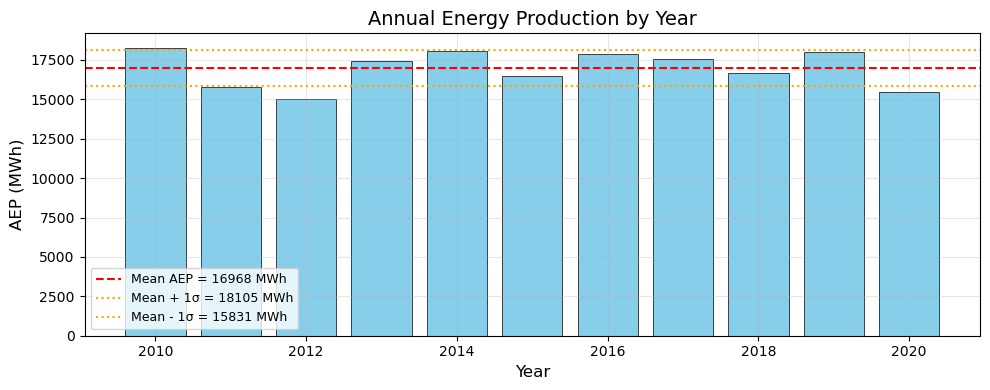

In [30]:
# variability per year for 1 turbine

df_wind['year'] = df_wind.index.year

annual_hours = df_wind.groupby('year').size() * dt_hours
annual_aep_MWh = df_wind.groupby('year')['power_kW'].sum() * dt_hours / 1000  # convert to MWh
annual_CF = annual_aep_MWh / (P_rated_kW * annual_hours / 1000)

print("Annual AEP and Capacity Factor by Year:")
summary = pd.DataFrame({'AEP (MWh)': annual_aep_MWh.round(1),
                         'CF (%)': (annual_CF * 100).round(1)})
print(summary.to_string())
print(f"\nMean  AEP : {annual_aep_MWh.mean():.1f} MWh  |  CF: {annual_CF.mean()*100:.1f}%")
print(f"Std   AEP : {annual_aep_MWh.std():.1f} MWh")
print(f"CV        : {annual_aep_MWh.std()/annual_aep_MWh.mean()*100:.1f}%")
print(f"Min   AEP : {annual_aep_MWh.min():.1f} MWh  ({annual_aep_MWh.idxmin()})")
print(f"Max   AEP : {annual_aep_MWh.max():.1f} MWh  ({annual_aep_MWh.idxmax()})")


#plot 
plt.figure(figsize=(10, 4))
plt.bar(annual_aep_MWh.index, annual_aep_MWh.values, color='skyblue', edgecolor='black', linewidth=0.5)
plt.axhline(annual_aep_MWh.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean AEP = {annual_aep_MWh.mean():.0f} MWh')
plt.axhline(annual_aep_MWh.mean() + annual_aep_MWh.std(), color='orange', linestyle=':', linewidth=1.5, label=f'Mean + 1σ = {(annual_aep_MWh.mean() + annual_aep_MWh.std()):.0f} MWh')
plt.axhline(annual_aep_MWh.mean() - annual_aep_MWh.std(), color='orange', linestyle=':', linewidth=1.5, label=f'Mean - 1σ = {(annual_aep_MWh.mean() - annual_aep_MWh.std()):.0f} MWh')
plt.xlabel('Year', fontsize=12)
plt.ylabel('AEP (MWh)', fontsize=12)
plt.title('Annual Energy Production by Year', fontsize=14)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{power_production_dir}/annual_aep.png", dpi=300, bbox_inches='tight')
plt.show()

CF of 38.7%, slightly below the typical 40-60%, which makes sense because those reference values are more for the northsea and we are analysing the atlantic in portugal coast


Number of turbines: 5

similar energy production to wind float atlantic



aligned in ENE - WSW line, perpendicular to the dominant wind direction
 

In [44]:
#wake effect

N_turbines = 5
D = 126  # m rotor diameter
s_D = 7 # spacing in diameters
x = s_D * D  # m inter-turbine distance
k_wake = 0.04
CT_rated = np.interp(11.4, U_T, CT)  # CT at rated speed

#worst case: fully aligned array 
deficit_per_row = (1 - np.sqrt(1 - CT_rated)) / (1 + k_wake * x / D)**2
print(f"CT at rated speed (11.4 m/s): {CT_rated:.3f}")
print(f"Jensen wake deficit per row (7D, CT={CT_rated:.3f}): {deficit_per_row*100:.1f}%")

#cumulative deficits for rows 
U0 = 1.0
U_worst = [U0]
for i in range(1, N_turbines):
    U_worst.append(max(U0 - i * deficit_per_row, 0.0))
P_rel_worst = [(u/U0)**3 for u in U_worst]
eta_worst = np.mean(P_rel_worst)

print(f"\nWorst case (fully aligned with wind):")
print(f"  Relative wind speed : {[f'{u:.3f}' for u in U_worst]}")
print(f"  Relative power      : {[f'{p:.3f}' for p in P_rel_worst]}")
print(f"  Array efficiency    : {eta_worst*100:.1f}%")

#more realistic case
#zero wake interaction for dominant sector
#remaining ~40-45% for other directions -> partial wakes
eta_array = 0.92
print(f"\nRealistic case (ENE-WSW layout, perpendicular to dominant NNW):")
print(f"  Dominant NNW sector frequency : ~55-60% of hours")
print(f"  Array efficiency η_array      : {eta_array*100:.0f}%")


CT at rated speed (11.4 m/s): 0.795
Jensen wake deficit per row (7D, CT=0.795): 33.4%

Worst case (fully aligned with wind):
  Relative wind speed : ['1.000', '0.666', '0.332', '0.000', '0.000']
  Relative power      : ['1.000', '0.295', '0.037', '0.000', '0.000']
  Array efficiency    : 26.6%

Realistic case (ENE-WSW layout, perpendicular to dominant NNW):
  Dominant NNW sector frequency : ~55-60% of hours
  Array efficiency η_array      : 92%


In [48]:
#farm AEP
AEP_farm_noWake_MWh = AEP_annual_MWh * N_turbines
AEP_farm_MWh = AEP_annual_MWh * N_turbines* eta_array
AEP_farm_GWh = AEP_farm_MWh / 1000

P_rated_farm_kW = P_rated_kW * N_turbines 
CF_farm = AEP_farm_MWh / (P_rated_farm_kW * 8760 /1000)

annual_farm_aep_MWh = AEP_annual_MWh * N_turbines * eta_array
annual_farm_CF = annual_farm_aep_MWh / (P_rated_farm_kW * 8760 /1000)

print(f"Installed capacity             : {P_rated_farm_kW/1000:.1f} MW")
print(f"AEP without wake losses        : {AEP_farm_noWake_MWh:.0f}  MWh/yr")
print(f"AEP with wake losses (η={eta_array*100:.0f}%) : {AEP_farm_MWh:.0f}  MWh/yr  ({AEP_farm_GWh:.2f} GWh/yr)")
print(f"Farm Capacity Factor           : {CF_farm*100:.1f}%")

Installed capacity             : 25.0 MW
AEP without wake losses        : 84839  MWh/yr
AEP with wake losses (η=92%) : 78052  MWh/yr  (78.05 GWh/yr)
Farm Capacity Factor           : 35.6%


AttributeError: 'numpy.float64' object has no attribute 'index'

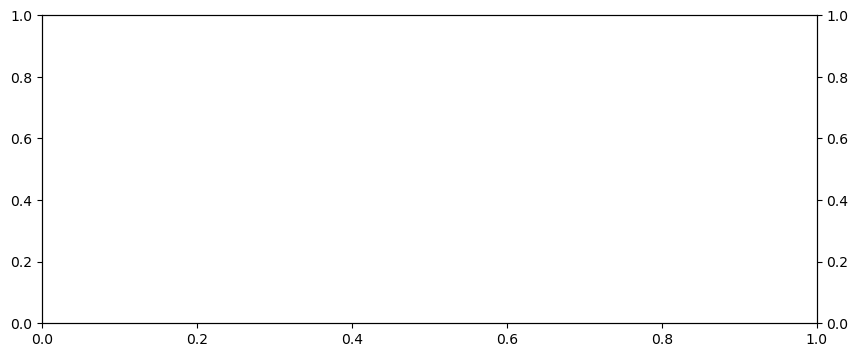

In [49]:
# Plot: Farm Annual AEP and CF (Capacity Factor) variability
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

# bar chart — farm AEP per year
ax1.bar(annual_farm_aep_MWh.index, annual_farm_aep_MWh.values,
        color='steelblue', edgecolor='black', linewidth=0.5, alpha=0.85,
        label='Farm AEP (with wake)')

# mean and ±1σ (standard deviation) lines
ax1.axhline(annual_farm_aep_MWh.mean(), color='red', linestyle='--', linewidth=1.5,
            label=f'Mean = {annual_farm_aep_MWh.mean():.0f} MWh/yr')
ax1.axhline(annual_farm_aep_MWh.mean() + annual_farm_aep_MWh.std(),
            color='orange', linestyle=':', linewidth=1.5,
            label=f'+1σ = {annual_farm_aep_MWh.mean() + annual_farm_aep_MWh.std():.0f} MWh/yr')
ax1.axhline(annual_farm_aep_MWh.mean() - annual_farm_aep_MWh.std(),
            color='orange', linestyle=':', linewidth=1.5,
            label=f'-1σ = {annual_farm_aep_MWh.mean() - annual_farm_aep_MWh.std():.0f} MWh/yr')

# CF (Capacity Factor) line on secondary axis
ax2.plot(annual_farm_CF.index, annual_farm_CF.values * 100,
         'ko-', linewidth=1.5, markersize=5, label='Farm CF (%)')
ax2.set_ylabel('Capacity Factor CF (%)', fontsize=11)
ax2.set_ylim(0, 50)

# axes labels and title
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Farm AEP (MWh/yr)', fontsize=11)
ax1.set_title('Annual Farm Energy Production & Capacity Factor — 5 × NREL 5-MW', fontsize=13)
ax1.set_xticks(annual_farm_aep_MWh.index)

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='lower left')

ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{power_production_dir}/annual_aep_farm.png", dpi=300, bbox_inches='tight')
plt.show()

# summary table
print("\nAnnual Farm AEP (Annual Energy Production) and CF (Capacity Factor):")
farm_summary = pd.DataFrame({
    'Farm AEP (MWh)': annual_farm_aep_MWh.round(0),
    'Farm CF (%)':    (annual_farm_CF * 100).round(2),
})
print(farm_summary.to_string())
print(f"\nMean Farm AEP : {annual_farm_aep_MWh.mean():.0f} MWh/yr")
print(f"Std  Farm AEP : {annual_farm_aep_MWh.std():.0f} MWh/yr")
print(f"CoV  (Coefficient of Variation) : {annual_farm_aep_MWh.std()/annual_farm_aep_MWh.mean()*100:.1f}%")
print(f"Min  Farm AEP : {annual_farm_aep_MWh.min():.0f} MWh/yr  ({annual_farm_aep_MWh.idxmin()})")
print(f"Max  Farm AEP : {annual_farm_aep_MWh.max():.0f} MWh/yr  ({annual_farm_aep_MWh.idxmax()})")
print(f"Mean Farm CF  : {annual_farm_CF.mean()*100:.1f}%")
print(f"\nWindFloat Atlantic (reference)  : ~78,000 MWh/yr")
print(f"Farm AEP / WindFloat Atlantic   : {annual_farm_aep_MWh.mean()/78000*100:.0f}%")